In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
df = pd.read_csv(r'example_data_1_PHYS_433_533.csv')

In [6]:
df

,f_res,max_power_dBm
0,3000,-54.0
1,3002,-54.1
2,3004,-54.0
3,3006,-53.9
4,3008,-53.8
...,...,...
996,4992,-63.8
997,4994,-63.3
998,4996,-63.3
999,4998,-63.8


In [9]:
frequency = df['f_res']
power_dbm = df['max_power_dBm']

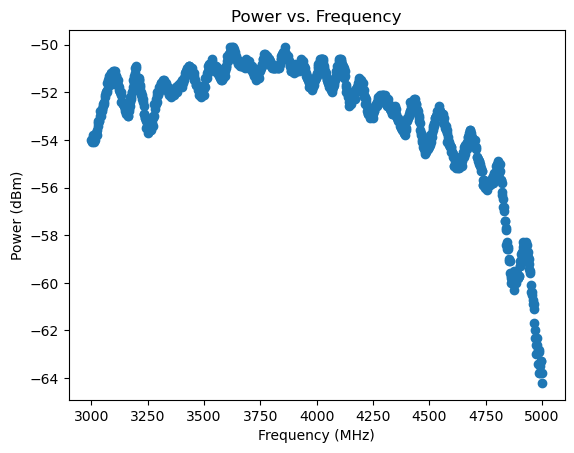

In [10]:
plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.scatter(frequency, power_dbm)
plt.show()

[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


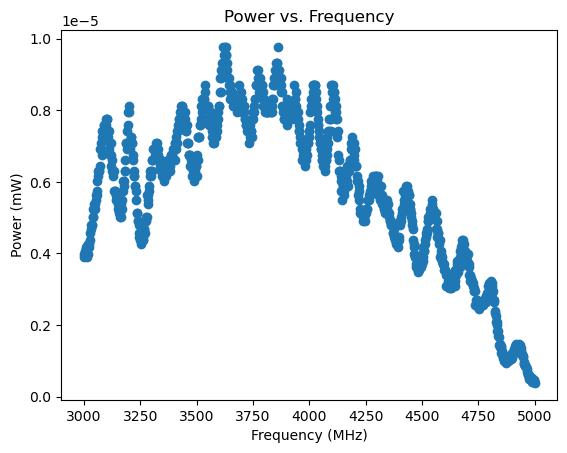

In [14]:
power_mW = 10 ** (np.array(power_dbm) / 10)
print(power_mW[:5])

plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency, power_mW)
plt.show()

In [15]:
mask = frequency > 4000
frequency_filtered = frequency[mask]
power_mW_filtered = power_mW[mask]

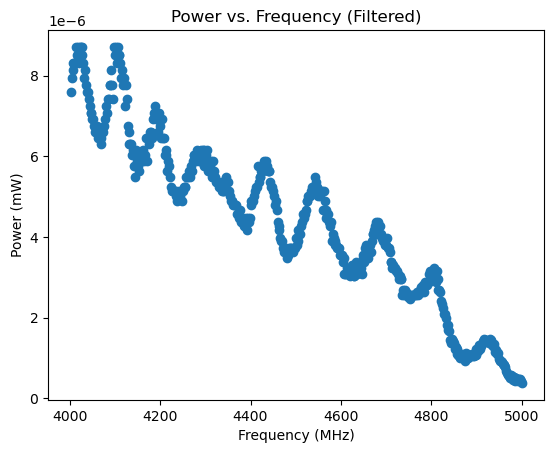

In [16]:
plt.title("Power vs. Frequency (Filtered)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency_filtered, power_mW_filtered)
plt.show()

In [17]:
def linear_fit(x, m, b):
    return m*x + b

In [20]:
popt, pcov = curve_fit(linear_fit, frequency_filtered, 
                       power_mW_filtered, p0=[-1, 4e-5])

print(popt)
print(pcov)

[-6.9385365e-09  3.5573120e-05]
[[ 9.43181763e-21 -4.24526114e-17]
 [-4.24526114e-17  1.91865186e-13]]


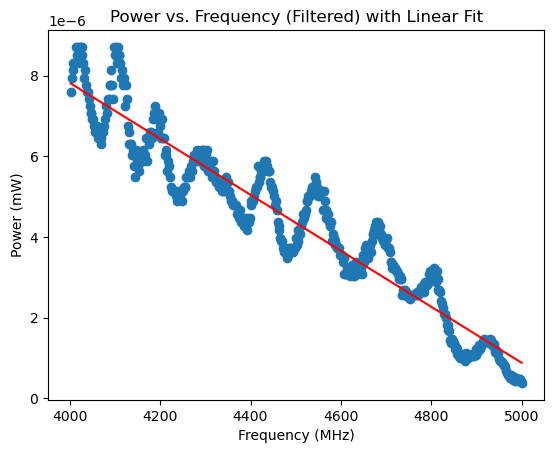

In [22]:
plt.title("Power vs. Frequency (Filtered) with Linear Fit")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency_filtered, power_mW_filtered)
plt.plot(frequency_filtered, linear_fit(frequency_filtered, popt[0],
                                        popt[1]), color='red')
plt.show()